In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

# Any results you write to the current directory are saved as output.

['train.csv', 'test.csv', 'gender_submission.csv']


Use pandas.read_csv() to import train.csv and assign it to the variable train.

Use DataFrame.shape to calculate the number of rows and columns in train, and assign the result to train_shape.

In [2]:
train = pd.read_csv("../input/train.csv")
train_shape = train.shape

test = pd.read_csv("../input/test.csv")
test_shape = test.shape

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Use DataFrame.pivot_table() to pivot the train dataframe: 
   - Use "Pclass" for the index parameter
   - Use "Survived" for the values parameter
   
Use dataframe.plot.bar() to plot the pivot table.

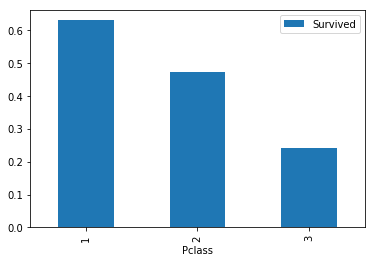

In [4]:
import matplotlib.pyplot as plt

Pclass_pivot = train.pivot_table(index="Pclass", values="Survived")
Pclass_pivot.plot.bar()
plt.show()

In [5]:
Pclass_pivot

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


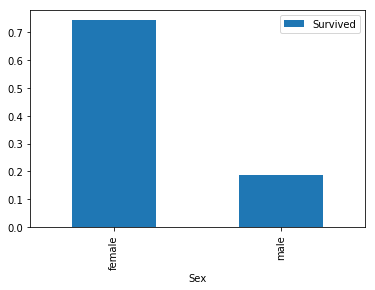

In [6]:
sex_pivot = train.pivot_table(index="Sex", values="Survived")
sex_pivot.plot.bar()
plt.show()

In [7]:
sex_pivot

,Survived
Sex,
female,0.742038
male,0.188908


   The Sex and PClass columns are what we called categorical features. That means that the values represented a few seperate options(for instance, whether the passenger was male or female).
   
The pandas.cut() function has two required parameters - the column we wish to cut, and a list of numbers which define the boundaries of our cuts. We are also going to use the optional parameter labels, which takes a list of labels for the resultant bins. This will make it easier for us to understand our results.

- uses the pandas.fillna() method to fill all of the missing values with -0.5
- cuts the Age column into three segments: Missing, Child, and Adult using pandas.cut().

We then use that function on both the train and test dataframes.

    def process_age(df,cut_points,label_names):
        df["Age"] = df["Age"].fillna(-0.5)
        df["Age_categories"] = pd.cut(df["Age"],cut_points,labels=label_names)
        return df

    cut_points = [-1,0,18,100]
    label_names = ["Missing","Child","Adult"]

    train = process_age(train,cut_points,label_names)
    test = process_age(test,cut_points,label_names)
    
    
Note that the cut_points list has one more element than the label_names list, since it needs to define the upper boundary for the last segment.

Create the cut_points and label_names lists to split the Age column into six categories:
- Missing, from -1 to 0
- Infant, from 0 to 5
- Child, from 5 to 12
- Teenager, from 12 to 18
- Young Adult, from 18 to 35
- Adult, from 35 to 60
- Senior, from 60 to 100

- Apply the process_age() function on the train dataframe, assigning the result to train.
- Apply the process_age() function on the test dataframe, assigning the result to test.
Use DataFrame.pivot_table() to pivot the train dataframe by the Age_categories column.
Use DataFrame.plot.bar() to plot the pivot table.

In [8]:
def process_age(df, cut_points, label_names):
    df["Age"] = df["Age"].fillna(-.5)
    df["Age_categories"] = pd.cut(df["Age"], cut_points, labels=label_names)
    return df

In [9]:
cut_points = [-1, 0, 5, 12, 18, 35, 60, 100]
label_names = ["Missing", "Infant", "Child", "Teenager", "Young Adult", "Adult", "Senior"]

In [10]:
train = process_age(train, cut_points, label_names)
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_categories
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Young Adult
5,6,0,3,"Moran, Mr. James",male,-0.5,0,0,330877,8.4583,NaN,Q,Missing
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Adult
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Infant
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,Young Adult
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,Teenager


In [11]:
test = process_age(test, cut_points, label_names)
test.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_categories
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Young Adult
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Adult
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Senior
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Young Adult
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Young Adult
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S,Teenager
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q,Young Adult
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S,Young Adult
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C,Teenager
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S,Young Adult


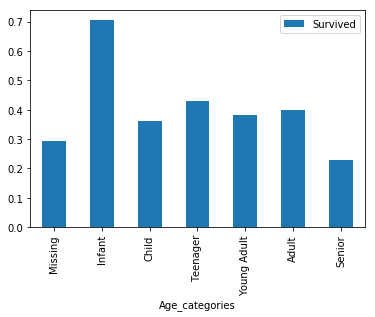

In [12]:
train.pivot_table(index="Age_categories", values="Survived").plot.bar()
plt.show()


So far we have identified three columns that may be useful for predicting survival:
Sex
Pclass
Age, or more specifically our newly created Age_categories
Before we build our model, we need to prepare these columns for machine learning. Most machine learning algorithms can't understand text labels, so we have to convert our values into numbers.
Additionally, we need to be careful that we don't imply any numeric relationship where there isn't one. If we think of the values in the Pclass column, we know they are 1, 2, and 3. You can confirm this by running the following code in your console:

    >>> train["Pclass"].value_counts()



While the class of each passenger certainly has some sort of ordered relationship, the relationship between each class is not the same as the relationship between the numbers 1, 2, and 3. For instance, class 2 isn't "worth" double what class 1 is, and class 3 isn't "worth" triple what class 1 is.
In order to remove this relationship, we can create dummy columns for each unique value in Pclass:

Rather than doing one-hot encoding manually, we can use the pandas.get_dummies() function, which will generate columns shown in the diagram above.

The following code creates a function to create the dummy columns for the Pclass column and add it back to the original dataframe. It then applies that function the train and test dataframes.

Let's use that function to create dummy columns for both the Sex and Age_categories columns.

In [13]:
def create_dummies(df, column_name):
    dummies = pd.get_dummies(df[column_name], prefix=column_name)
    df = pd.concat([df, dummies], axis=1)
    return df

In [14]:
train = create_dummies(train, "Pclass")
test = create_dummies(test, "Pclass")

train = create_dummies(train, "Sex")
test = create_dummies(test, "Sex")

train = create_dummies(train, "Age_categories")
test = create_dummies(test, "Age_categories")

In [15]:
train.head(10)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Pclass_3,Sex_female,Sex_male,Age_categories_Missing,Age_categories_Infant,Age_categories_Child,Age_categories_Teenager,Age_categories_Young Adult,Age_categories_Adult,Age_categories_Senior
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,1,0,1,0,0,0,0,1,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,0,1,0,0,0,0,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,1,1,0,0,0,0,0,1,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,0,1,0,0,0,0,0,1,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,1,0,1,0,0,0,0,1,0,0
5,6,0,3,"Moran, Mr. James",male,-0.5,0,0,330877,8.4583,...,1,0,1,1,0,0,0,0,0,0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,...,0,0,1,0,0,0,0,0,1,0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,...,1,0,1,0,1,0,0,0,0,0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,...,1,1,0,0,0,0,0,1,0,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,...,0,1,0,0,0,0,1,0,0,0


Now that our data has been prepared, we are ready to train our first model. The first model we will use is called Logistic Regression, which is often the first model you will train when performing classification.
We will be using the scikit-learn library as it has many tools that make performing machine learning easier. The scikit-learn workflow consists of four main steps:
    
- Instantiate (or create) the specific machine learning model you want to use
- Fit the model to the training data
- Use the model to make predictions
- Evaluate the accuracy of the predictions

Each model in scikit-learn is implemented as a separate class and the first step is to identify the class we want to create an instance of. In our case, we want to use the LogisticRegression class.

We'll start by looking at the first two steps. First, we need to import the class:


        from sklearn.linear_model import LogisticRegression

Next, we create a LogisticRegression object:


    lr = LogisticRegression()

Lastly, we use the LogisticRegression.fit() method to train our model. The .fit() method accepts two arguments: X and y. X must be a two dimensional array (like a dataframe) of the features that we wish to train our model on, and y must be a one-dimensional array (like a series) of our target, or the column we wish to predict.


    columns = ['Pclass_2', 'Pclass_3', 'Sex_male']
    lr.fit(train[columns], train['Survived'])

The code above fits (or trains) our LogisticRegression model using three columns: Pclass_2, Pclass_3, and Sex_male.
Let's train our model using all of the columns we created in the previous screen.

In [16]:
columns = ['Pclass_1', 'Pclass_2', 'Pclass_3', 'Sex_female', 'Sex_male',
       'Age_categories_Missing','Age_categories_Infant',
       'Age_categories_Child', 'Age_categories_Teenager',
       'Age_categories_Young Adult', 'Age_categories_Adult',
       'Age_categories_Senior']

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(train[columns], train["Survived"])

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False)

Congratulations, you've trained your first machine learning model! Our next step is to find out how accurate our model is, and to do that, we'll have to make some predictions.
If you recall from earlier, we do have a test dataframe that we could use to make predictions. We could make predictions on that data set, but because it doesn't have the Survived column we would have to submit it to Kaggle to find out our accuracy. This would quickly become a pain if we had to submit to find out the accuracy every time we optimized our model.
We could also fit and predict on our train dataframe, however if we do this there is a high likelihood that our model will overfit, which means it will perform well because we're testing on the same data we've trained on, but then perform much worse on new, unseen data.
Instead we can split our train dataframe into two:

- One part to train our model on (often 80% of the observations)
- One part to make predictions with and test our model (often 20% of the observations)

The convention in machine learning is to call these two parts train and test. This can become confusing, since we already have our test dataframe that we will eventually use to make predictions to submit to Kaggle. To avoid confusion, from here on, we're going to call this Kaggle 'test' data holdout data, which is the technical name given to this type of data used for final predictions.

The scikit-learn library has a handy model_selection.train_test_split() function that we can use to split our data. train_test_split() accepts two parameters, X and y, which contain all the data we want to train and test on, and returns four objects: train_X, train_y, test_X, test_y:

Here's what the syntax for creating these four objects looks like:

    from sklearn.model_selection import train_test_split

    columns = ['Pclass_2', 'Pclass_3', 'Sex_male']

    all_X = train[columns]
    all_y = train['Survived']

    train_X, test_X, train_y, test_y = train_test_split(
        all_X, all_y, test_size=0.2,random_state=0)
        
You'll notice that there are two other parameters we used: test_size, which lets us control what proportions our data are split into, and random_state. The train_test_split() function randomizes observations before dividing them, and setting a random seed means that our results will be reproducible, which is important if you are collaborating, or need to produce consistent results each time (which our answer checker requires).

Use the model_selection.train_test_split() function to split the train dataframe using the following parameters:
- test_size of 0.2.
- random_state of 0.
Assign the four returned objects to train_X, test_X, train_y, and test_y.

In [17]:
holdout = test # from now on we will refer to this
               # dataframe as the holdout data

from sklearn.model_selection import train_test_split

columns = ['Pclass_1', 'Pclass_2', 'Pclass_3', 'Sex_female', 'Sex_male',
       'Age_categories_Missing','Age_categories_Infant',
       'Age_categories_Child', 'Age_categories_Teenager',
       'Age_categories_Young Adult', 'Age_categories_Adult',
       'Age_categories_Senior']

train_x, test_x, train_y, test_y = train_test_split(train[columns], train["Survived"], test_size=0.2, random_state=0)


Now that we have our data split into train and test sets, we can fit our model again on our training set, and then use that model to make predictions on our test set.
Once we have fit our model, we can use the LogisticRegression.predict() method to make predictions.
The predict() method takes a single parameter X, a two dimensional array of features for the observations we wish to predict. X must have the exact same features as the array we used to fit our model. The method returns single dimensional array of predictions.

    lr = LogisticRegression()
    lr.fit(train_X, train_y)
    predictions = lr.predict(test_X)
    
There are a number of ways to measure the accuracy of machine learning models, but when competing in Kaggle competitions you want to make sure you use the same method that Kaggle uses to calculate accuracy for that specific competition.

In this case, the evaluation section for the Titanic competition on Kaggle tells us that our score calculated as "the percentage of passengers correctly predicted". This is by far the most common form of accuracy for binary classification.

Again, scikit-learn has a handy function we can use to calculate accuracy: metrics.accuracy_score(). The function accepts two parameters, y_true and y_pred, which are the actual values and our predicted values respectively, and returns our accuracy score.

    from sklearn.metrics import accuracy_score
    accuracy = accuracy_score(test_y, predictions)

In [18]:
from sklearn.metrics import accuracy_score

lr = LogisticRegression()
lr.fit(train_x, train_y)
predictions = lr.predict(test_x)

accuracy = accuracy_score(test_y, predictions)

accuracy

0.8100558659217877

Our model has an accuracy score of 81.0% when tested against our 20% test set. Given that this data set is quite small, there is a good chance that our model is overfitting, and will not perform as well on totally unseen data.
To give us a better understanding of the real performance of our model, we can use a technique called cross validation to train and test our model on different splits of our data, and then average the accuracy scores.



The most common form of cross validation, and the one we will be using, is called k-fold cross validation. 'Fold' refers to each different iteration that we train our model on, and 'k' just refers to the number of folds. In the diagram above, we have illustrated k-fold validation where k is 5.

We will use scikit-learn's model_selection.cross_val_score() function to automate the process. The basic syntax for cross_val_score() is:

    cross_val_score(estimator, X, y, cv=None)
    
- estimator is a scikit-learn estimator object, like the LogisticRegression() objects we have been creating.
- X is all features from our data set.
- y is the target variables.
- cv specifies the number of folds.

The function returns a numpy ndarray of the accuracy scores of each fold.
It's worth noting, the cross_val_score() function can use a variety of cross validation techniques and scoring types, but it defaults to k-fold validation and accuracy scores for our input types.

- Instantiate a new LogisticRegression() object, lr.
- Use model_selection.cross_val_score() to perform cross-validation on our data and assign the results to scores:
- Use the newly created lr as the estimator.
- Use all_X and all_y as the input data.
- Specify 10 folds to be used.
- Use the numpy.mean() function to calculate the mean of scores and assign the result to accuracy.
- Print the variables scores and accuracy.

In [19]:
from sklearn.model_selection import cross_val_score
import numpy as np

lr = LogisticRegression()

scores = cross_val_score(lr, train[columns], train["Survived"], cv=10)

accuracy = np.mean(scores)

print(scores)
print(accuracy)

[0.8        0.81111111 0.7752809  0.87640449 0.80898876 0.78651685
 0.76404494 0.76404494 0.83146067 0.80681818]
0.8024670865963002


From the results of our k-fold validation, you can see that the accuracy number varies with each fold - ranging between 76.4% and 87.6%. This demonstrates why cross validation is important.
As it happens, our average accuracy score was 80.2%, which is not far from the 81.0% we got from our simple train/test split, however this will not always be the case, and you should always use cross-validation to make sure the error metrics you are getting from your model are accurate.
We are now ready to use the model we have built to train our final model and then make predictions on our unseen holdout data, or what Kaggle calls the 'test' data set.

In [22]:
lr = LogisticRegression()

lr.fit(train[columns], train["Survived"])

holdout_predictions = lr.predict(holdout[columns])

In [23]:
holdout_predictions

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

The last thing we need to do is create a submission file. Each Kaggle competition can have slightly different requirements for the submission file. Here's what is specified on the Titanic competition evaluation page:
> You should submit a csv file with exactly 418 entries plus a header row. Your submission will show an error if you have extra columns (beyond PassengerId and Survived) or rows.
The file should have exactly 2 columns:
- PassengerId (sorted in any order)
- Survived (contains your binary predictions: 1 for survived, 0 for deceased)


We will need to create a new dataframe that contains the holdout_predictions we created in the previous screen and the PassengerId column from the holdout dataframe. We don't need to worry about matching the data up, as both of these remain in their original order.
To do this, we can pass a dictionary to the pandas.DataFrame() function:

    holdout_ids = holdout["PassengerId"]
    submission_df = {"PassengerId": holdout_ids,
                     "Survived": holdout_predictions}
    submission = pd.DataFrame(submission_df)
    
Finally, we'll use the DataFrame.to_csv() method to save the dataframe to a CSV file. We need to make sure the index parameter is set to False, otherwise we will add an extra column to our CSV.

In [24]:
holdout_ids = holdout["PassengerId"]
submission_df = {
    "PassengerId":holdout_ids,
    "Survived":holdout_predictions
}
submission = pd.DataFrame(submission_df)

Create a dataframe submission that matches Kaggle's specification.
Use the to_csv() method to save the submission dataframe using the filename submission.csv, using the documentation to look up the correct syntax.

    submission.to_csv("submission.csv", index=False)

There are many things we can do to improve the accuracy of our model. Here are some that we will cover in the next two missions of this course:
Improving the features:
- Feature Engineering: Create new features from the existing data.
- Feature Selection: Select the most relevant features to reduce noise and overfitting.

Improving the model:
- Model Selection: Try a variety of models to improve performance.
- Hyperparameter Optimization: Optimize the settings within each particular machine learning model.